<a href="https://colab.research.google.com/github/HassaanDeveloper/AI-ML-Internship-Tasks/blob/main/Task_3/AI_ML_Internship_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)

In [ ]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Shape: (303, 14)

Column Names:
 ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:")
df.describe()

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 1

Data Types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


/tmp/ipykernel_19743/2970540687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='age', palette='Set2', ax=axes[1])
/tmp/ipykernel_19743/2970540687.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Disease', 'Disease'])


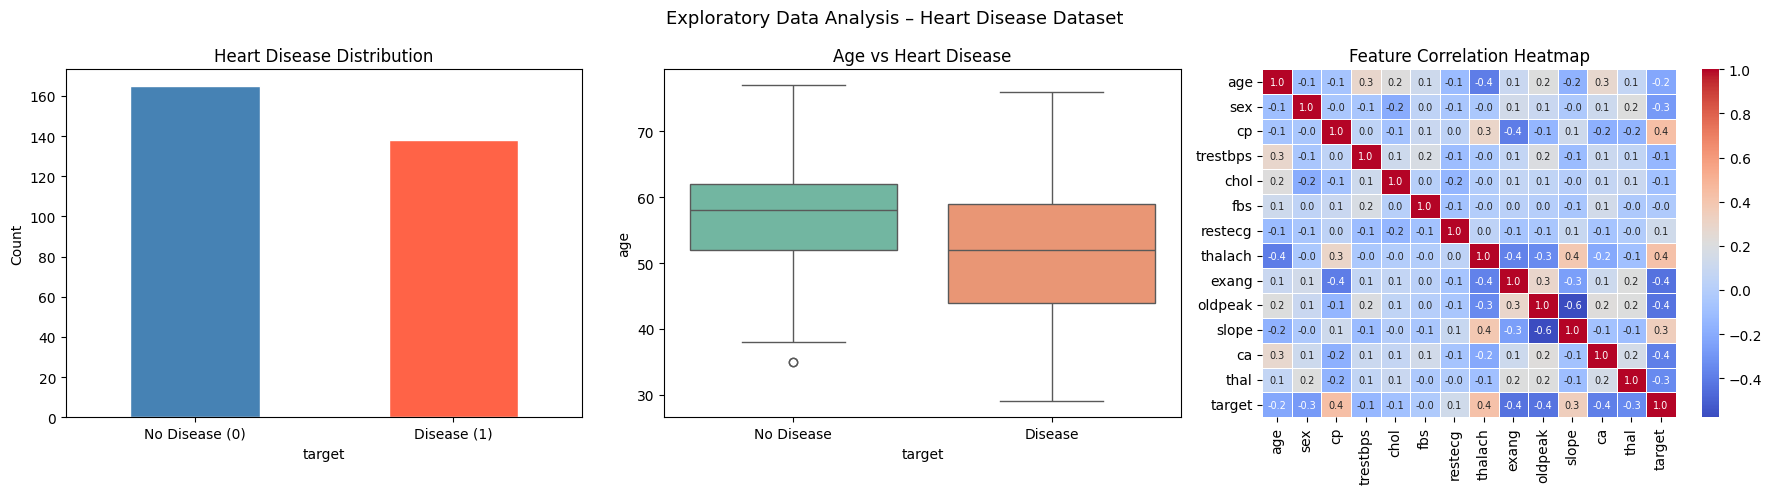

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Heart Disease Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Plot 2: Age vs Target
sns.boxplot(data=df, x='target', y='age', palette='Set2', ax=axes[1])
axes[1].set_title('Age vs Heart Disease')
axes[1].set_xticklabels(['No Disease', 'Disease'])

# Plot 3: Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[2], linewidths=0.5, annot_kws={"size": 7})
axes[2].set_title('Feature Correlation Heatmap')

plt.suptitle('Exploratory Data Analysis – Heart Disease Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 242
Testing samples:  61


In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(classification_report(y_test, lr_preds))

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, dt_preds)*100:.2f}%")
print(classification_report(y_test, dt_preds))

=== Logistic Regression ===
Accuracy: 80.33%
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

=== Decision Tree ===
Accuracy: 78.69%
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



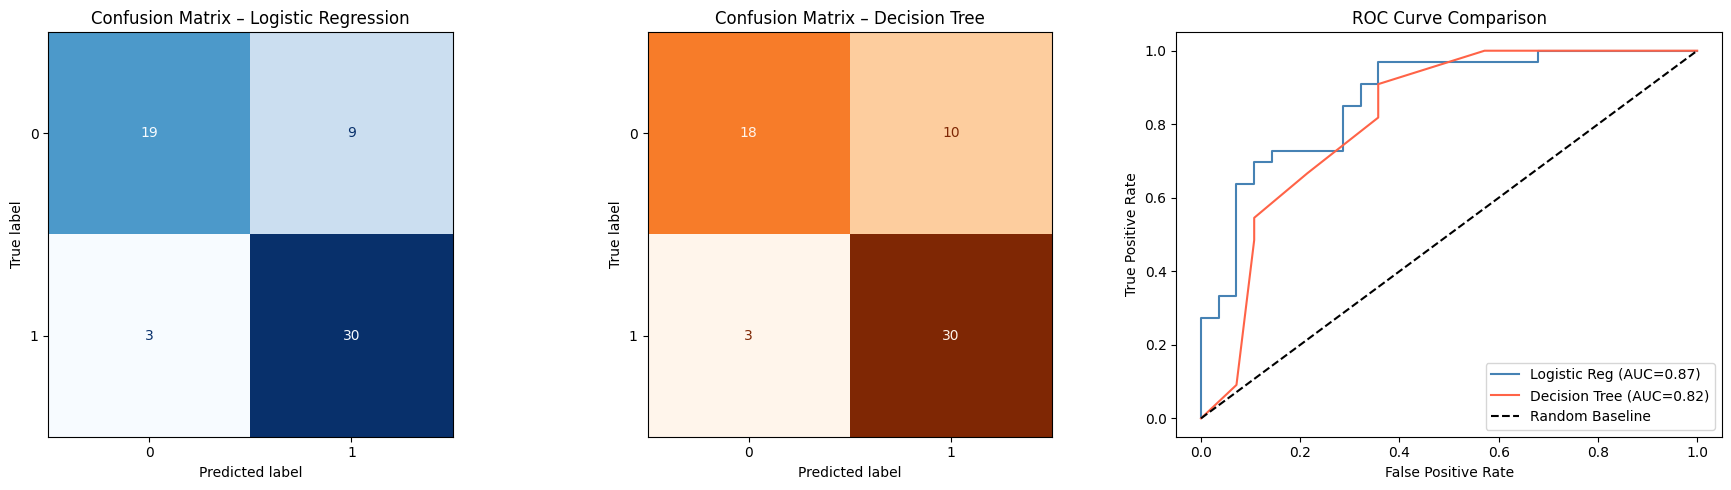

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Logistic Regression')

# Confusion Matrix - Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_preds, ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix – Decision Tree')

# ROC Curves
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt.predict_proba(X_test_scaled)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

axes[2].plot(lr_fpr, lr_tpr, label=f'Logistic Reg (AUC={auc(lr_fpr,lr_tpr):.2f})', color='steelblue')
axes[2].plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={auc(dt_fpr,dt_tpr):.2f})', color='tomato')
axes[2].plot([0,1],[0,1],'k--', label='Random Baseline')
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

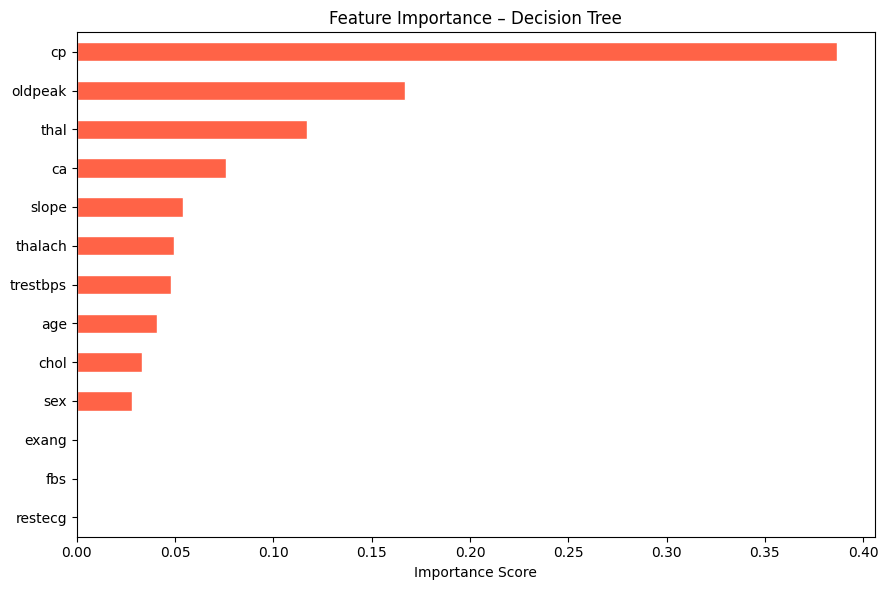


Top 5 Most Important Features:
cp         0.386753
oldpeak    0.166862
thal       0.116889
ca         0.076041
slope      0.053878
dtype: float64


In [ ]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='tomato', edgecolor='white')
plt.title('Feature Importance – Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance.sort_values(ascending=False).head())